# Cell-Cell Communication Prediction using Graph Neural Networks
### COMP-4740 — Winter 2026

| | |
|---|---|
| **Task** | Link prediction on cell-cell communication networks |
| **Models** | Baseline GNN · GCN · GAT |
| **Protocol** | 90-10 train-test split, balanced negative sampling (SEGCECO) |

### Datasets
| Name | Source | Tissue | Cells | Notes |
|---|---|---|---|---|
| HumanD1–D4 | Baron et al. 2016 (GSE84133) via SEGCECO | Human pancreas | 1303–3605 | Primary datasets |
| MouseD1–D2 | Baron et al. 2016 (GSE84133) via SEGCECO | Mouse pancreas | 822–1064 | Cross-species validation |
| KangPBMC | Kang et al. 2018 (GSE96583) via LIANA+ | Human PBMC | ~2400 | Cross-tissue validation |

## 0 · Setup

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import torch
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from src.utils import set_seed
set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')

PyTorch : 2.5.1
Device  : cpu


---
## Part 1 — Primary Datasets: Human Pancreas (SEGCECO)

Baron et al. 2016 human pancreas scRNA-seq data.  
Pre-processed edgelists and 300 IG-selected gene features from the SEGCECO GitHub repository.  
Graph = SoptSC-derived cell-cell communication network (individual cells as nodes).

In [2]:
from src.data_loader import load_all_human_datasets
from src.graph_builder import build_link_prediction_data
from src.trainer import split_data

print('Loading SEGCECO Human Pancreas datasets (HumanD1–D4)...')
human_raw = load_all_human_datasets(n_features=300)

human_splits = {}
for name, data in human_raw.items():
    lp = build_link_prediction_data(data)
    train, _, test = split_data(lp, test_ratio=0.1, seed=42)
    human_splits[name] = (train, test)

print('\nSplit summary:')
for name, (tr, te) in human_splits.items():
    n_train = tr.pos_edge_label_index.shape[1] + tr.neg_edge_label_index.shape[1]
    n_test  = te.pos_edge_label_index.shape[1] + te.neg_edge_label_index.shape[1]
    print(f'  {name}: train={n_train} | test={n_test}')

Loading SEGCECO Human Pancreas datasets (HumanD1–D4)...
[HumanD1] nodes=1930, edges=67882, features=300, cell-types=1
[HumanD2] nodes=1724, edges=60446, features=300, cell-types=1
[HumanD3] nodes=3597, edges=125700, features=300, cell-types=1
[HumanD4] nodes=1282, edges=45458, features=300, cell-types=1
[graph_builder] HumanD1 | 1930 nodes | 67882 positive CCN edges
[graph_builder] HumanD2 | 1724 nodes | 60446 positive CCN edges
[graph_builder] HumanD3 | 3597 nodes | 125700 positive CCN edges
[graph_builder] HumanD4 | 1282 nodes | 45458 positive CCN edges

Split summary:
  HumanD1: train=122188 | test=13576
  HumanD2: train=108804 | test=12088
  HumanD3: train=226260 | test=25140
  HumanD4: train=81826 | test=9090


In [ ]:
import os, pickle
from src.models import BaselineGNN, GCN, GAT
from src.trainer import train_model

HIDDEN_DIM = 128
EPOCHS     = 400
LR         = 1e-3

MODEL_DEFS = {
    'Baseline GNN': (BaselineGNN, {}),
    'GCN':          (GCN,         {}),
    'GAT':          (GAT,         {'heads': 4}),
}

human_results   = {}
human_histories = {}

for ds_name, (train_data, test_data) in human_splits.items():
    in_dim = train_data.x.shape[1]
    print(f'\n{"="*60}\n  {ds_name}  |  in_dim={in_dim}\n{"="*60}')
    human_results[ds_name]   = {}
    human_histories[ds_name] = {}

    for model_name, (ModelCls, kw) in MODEL_DEFS.items():
        print(f'\n  [{model_name}]')
        set_seed(42)
        model = ModelCls(in_dim=in_dim, hidden_dim=HIDDEN_DIM, **kw)
        _, metrics, history = train_model(
            model, train_data, test_data,
            epochs=EPOCHS, lr=LR, device=DEVICE, verbose=True
        )
        human_results[ds_name][model_name]   = metrics
        human_histories[ds_name][model_name] = history

os.makedirs('results', exist_ok=True)
with open('results/human_results.pkl', 'wb') as f:
    pickle.dump(human_results, f)
print('\nHuman pancreas training complete. Results saved to results/human_results.pkl')


### HumanD1

Model                  AUC-ROC    AUC-PR      Acc     Prec   Recall       F1
──────────────────────────────────────────────────────────────────────────
Baseline GNN            0.9741    0.9634   0.9383   0.8971   0.9903   0.9414
GCN                     0.9915    0.9879   0.9708   0.9476   0.9968   0.9716
GAT                     0.9816    0.9745   0.9512   0.9188   0.9898   0.9530


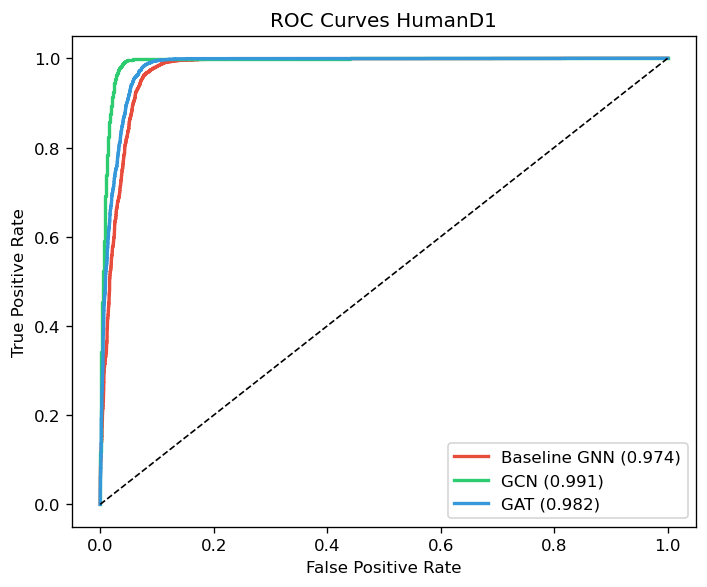

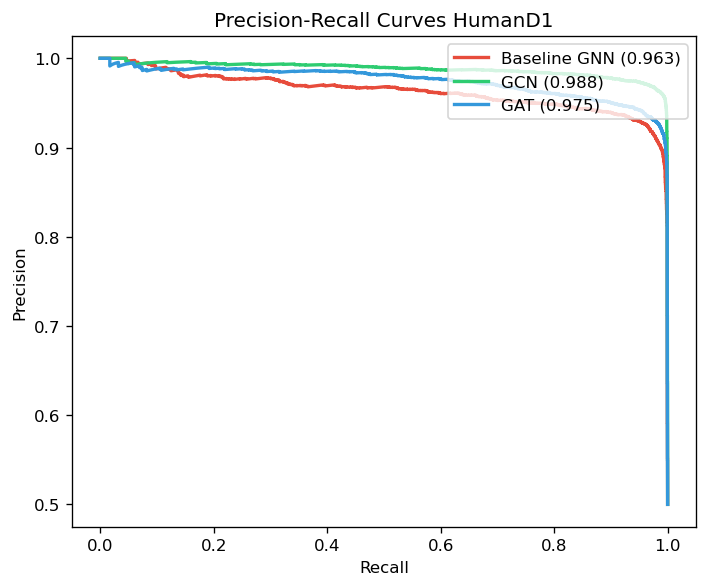


### HumanD2

Model                  AUC-ROC    AUC-PR      Acc     Prec   Recall       F1
──────────────────────────────────────────────────────────────────────────
Baseline GNN            0.9873    0.9803   0.9618   0.9323   0.9959   0.9630
GCN                     0.9948    0.9919   0.9796   0.9644   0.9959   0.9799
GAT                     0.9951    0.9923   0.9799   0.9670   0.9937   0.9802


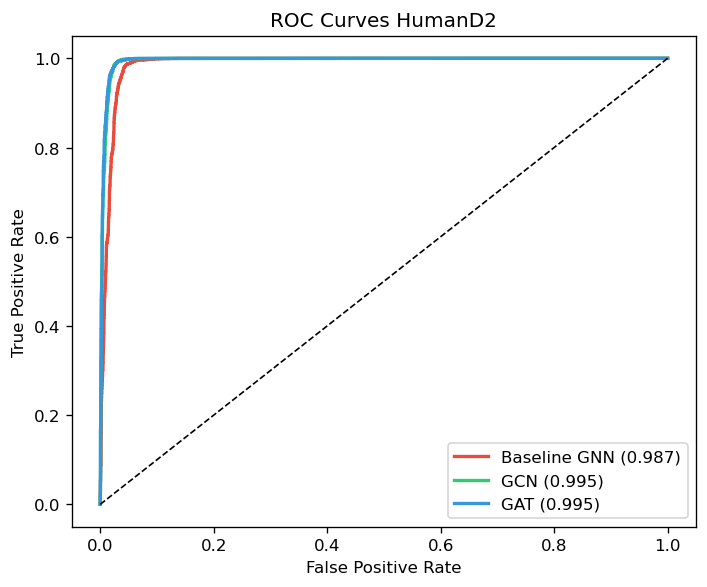

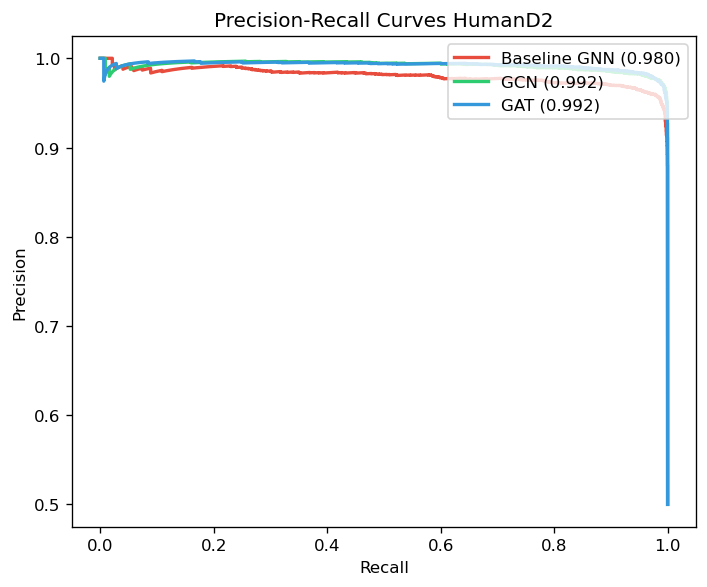


### HumanD3

Model                  AUC-ROC    AUC-PR      Acc     Prec   Recall       F1
──────────────────────────────────────────────────────────────────────────
Baseline GNN            0.9620    0.9427   0.9183   0.8703   0.9831   0.9233
GCN                     0.9960    0.9947   0.9791   0.9643   0.9950   0.9794
GAT                     0.9859    0.9769   0.9549   0.9238   0.9916   0.9565


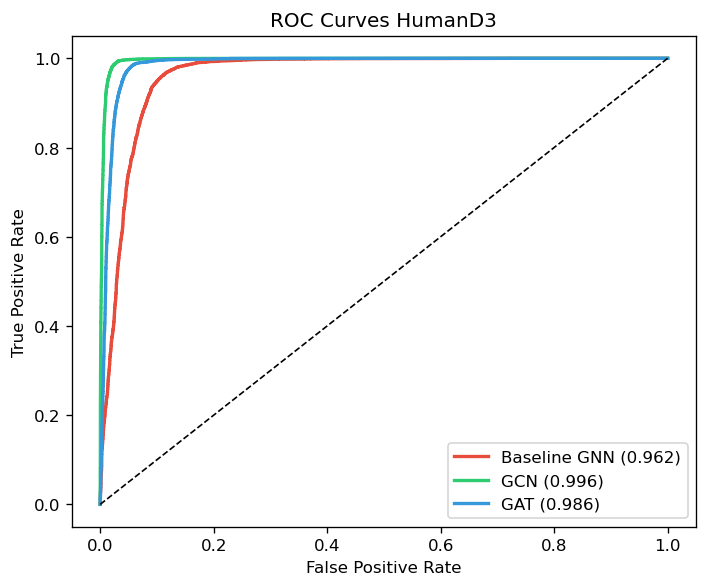

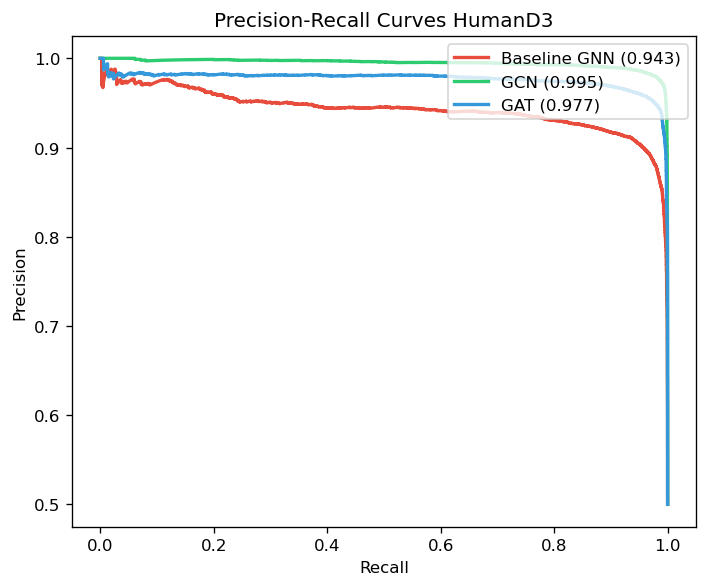


### HumanD4

Model                  AUC-ROC    AUC-PR      Acc     Prec   Recall       F1
──────────────────────────────────────────────────────────────────────────
Baseline GNN            0.9691    0.9527   0.9322   0.8899   0.9866   0.9357
GCN                     0.9751    0.9628   0.9424   0.9066   0.9864   0.9448
GAT                     0.9731    0.9596   0.9383   0.9018   0.9837   0.9410


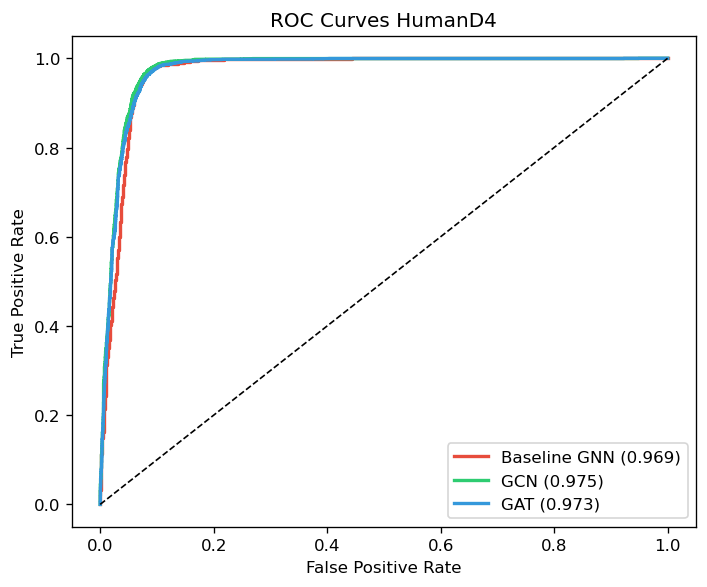

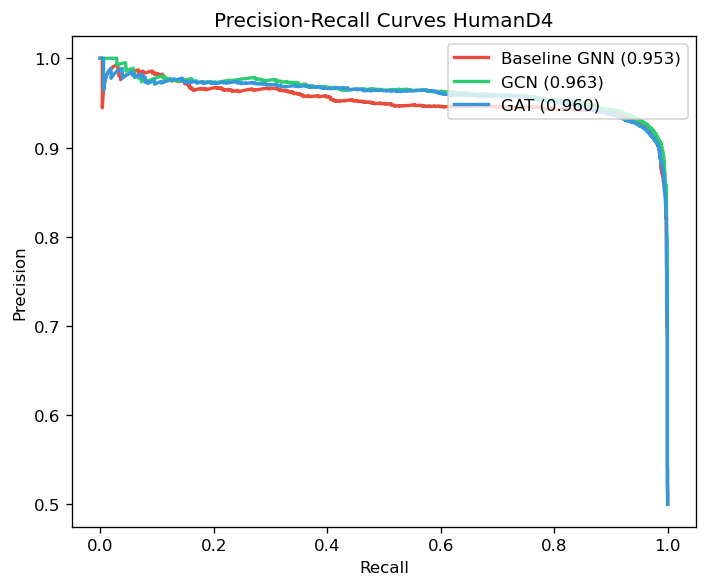

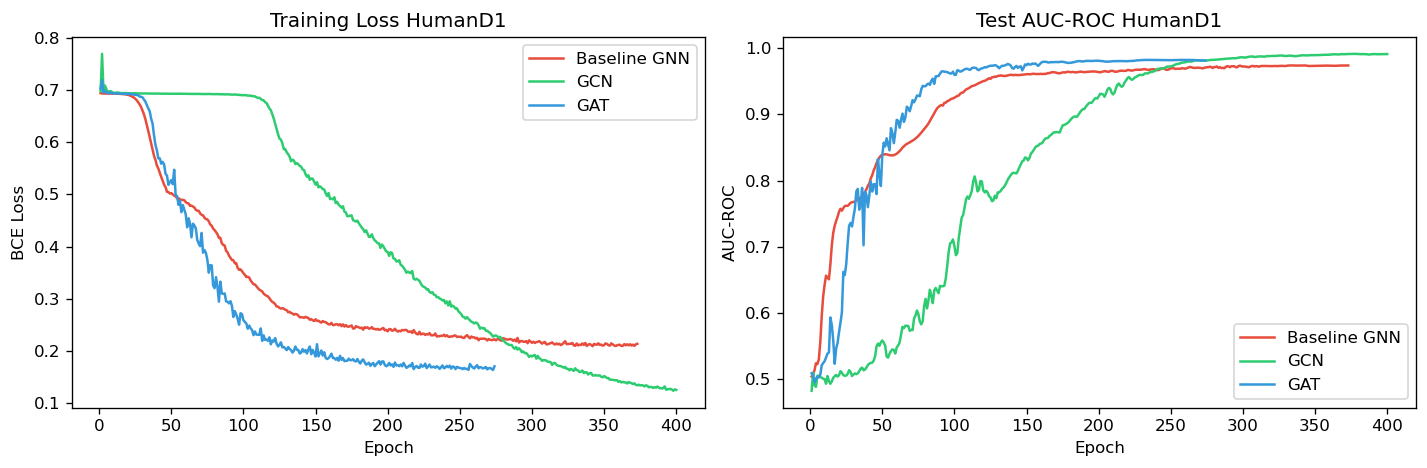

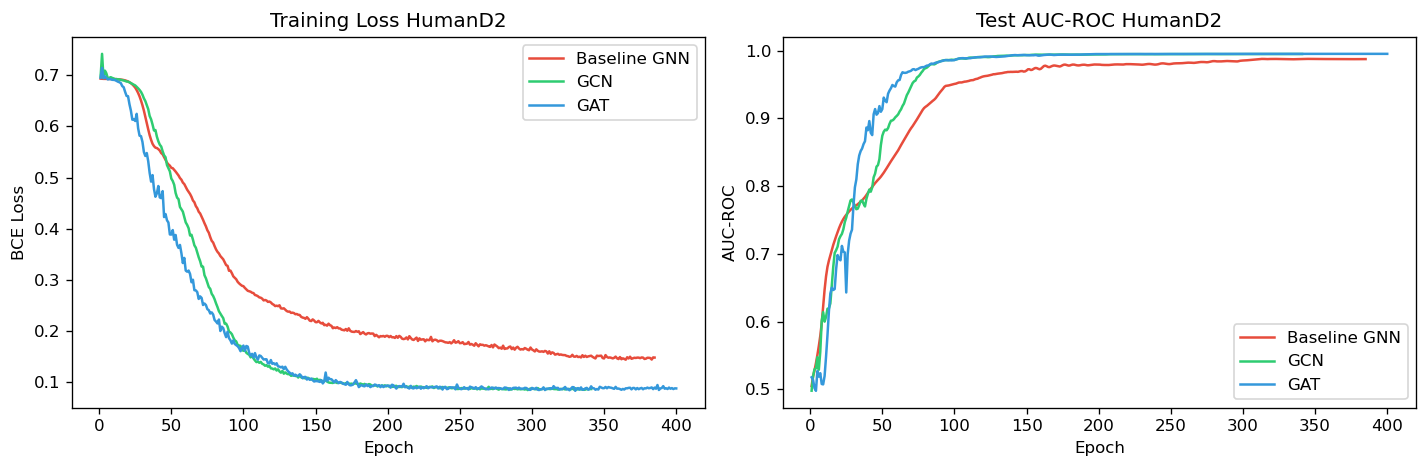

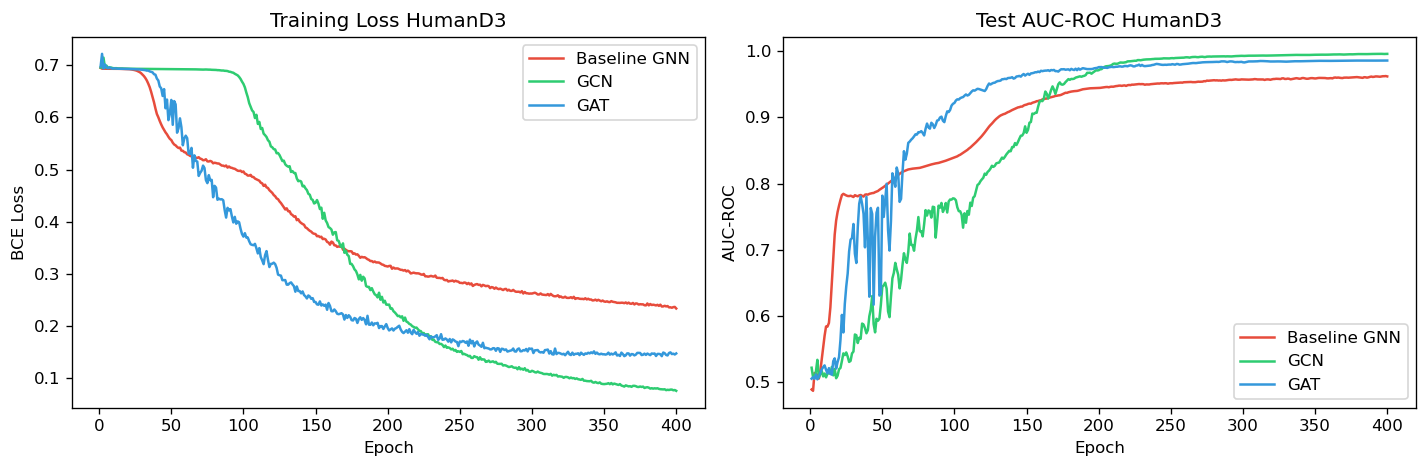

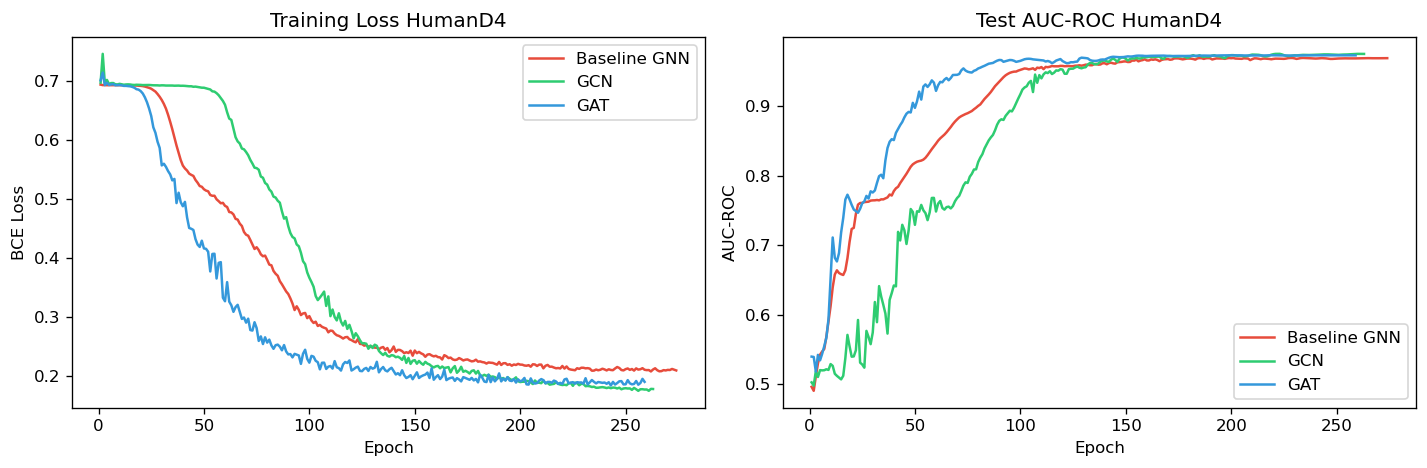

In [4]:
from src.utils import results_table, plot_roc_curves, plot_pr_curves, plot_training_history, plot_metric_comparison

for ds_name, model_results in human_results.items():
    print(f'\n### {ds_name}')
    results_table(model_results)
    plot_roc_curves(model_results, title=ds_name)
    plot_pr_curves(model_results,  title=ds_name)

for ds_name, histories in human_histories.items():
    plot_training_history(histories, title=ds_name)

---
## Part 2 — Secondary Dataset A: Mouse Pancreas (SEGCECO)

Baron et al. 2016 **mouse** pancreas — same SoptSC pipeline as human data.  
Tests **cross-species generalization** of our GNN architectures.

In [ ]:
import os, pickle, torch
from src.secondary_datasets import load_all_mouse_datasets
from src.graph_builder import build_link_prediction_data
from src.trainer import split_data, train_model
from src.models import BaselineGNN, GCN, GAT
from src.utils import set_seed

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HIDDEN_DIM = 128
EPOCHS     = 400
LR         = 1e-3
MODEL_DEFS = {
    'Baseline GNN': (BaselineGNN, {}),
    'GCN':          (GCN,         {}),
    'GAT':          (GAT,         {'heads': 4}),
}

print('Loading SEGCECO Mouse Pancreas datasets (MouseD1–D2)...')
mouse_raw = load_all_mouse_datasets(n_features=300)

mouse_splits = {}
for name, data in mouse_raw.items():
    lp = build_link_prediction_data(data)
    train, _, test = split_data(lp, test_ratio=0.1, seed=42)
    mouse_splits[name] = (train, test)

mouse_results   = {}
mouse_histories = {}

for ds_name, (train_data, test_data) in mouse_splits.items():
    in_dim = train_data.x.shape[1]
    print(f'\n{"="*60}\n  {ds_name}  |  in_dim={in_dim}\n{"="*60}')
    mouse_results[ds_name]   = {}
    mouse_histories[ds_name] = {}

    for model_name, (ModelCls, kw) in MODEL_DEFS.items():
        print(f'\n  [{model_name}]')
        set_seed(42)
        model = ModelCls(in_dim=in_dim, hidden_dim=HIDDEN_DIM, **kw)
        _, metrics, history = train_model(
            model, train_data, test_data,
            epochs=EPOCHS, lr=LR, device=DEVICE, verbose=True
        )
        mouse_results[ds_name][model_name]   = metrics
        mouse_histories[ds_name][model_name] = history

os.makedirs('results', exist_ok=True)
with open('results/mouse_results.pkl', 'wb') as f:
    pickle.dump(mouse_results, f)
print('\nMouse pancreas training complete. Results saved to results/mouse_results.pkl')

In [ ]:
from src.utils import results_table, plot_roc_curves, plot_pr_curves, plot_training_history

for ds_name, model_results in mouse_results.items():
    print(f'\n### {ds_name}')
    results_table(model_results)
    plot_roc_curves(model_results, title=ds_name)
    plot_pr_curves(model_results,  title=ds_name)

for ds_name, histories in mouse_histories.items():
    plot_training_history(histories, title=ds_name)

---
## Part 3 — Secondary Dataset B: Kang 2018 PBMC (LIANA+ Dataset)

**Kang et al. 2018** (GSE96583) — ~25k PBMCs from 8 lupus patients.  
Used as the tutorial dataset in **LIANA+** (the leading Python CCC framework).  
Cell types: CD4T, CD8T, B cells, NK, CD14 Monocytes, FCGR3A Monocytes, DCs, Megakaryocytes.

Graph construction: kNN cosine similarity graph on PCA embeddings (n=15 neighbours),  
mirroring the SoptSC cell similarity approach used in SEGCECO.  
This tests **cross-tissue generalization** (immune cells vs. pancreas).

> First run downloads ~200 MB from figshare — cached after that.

In [9]:
from src.secondary_datasets import load_kang_pbmc

print('Loading Kang 2018 PBMC (LIANA+ dataset)...')
kang_data = load_kang_pbmc(n_cells_per_type=300, n_features=300, n_neighbors=15)

Loading Kang 2018 PBMC (LIANA+ dataset)...
  Loading Kang 2018 PBMC dataset...
  Subsampled to 2232 cells across 8 cell types.


C:\Users\kapil\miniconda3\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  IG feature selection: 2000 -> 300 genes
[KangPBMC] nodes=2122, edges=45244, features=300, cell-types=8


In [13]:
import os, pickle, torch
from src.graph_builder import build_link_prediction_data
from src.trainer import split_data, train_model
from src.models import BaselineGNN, GCN, GAT
from src.utils import set_seed

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HIDDEN_DIM = 128
EPOCHS     = 400
LR         = 1e-3
MODEL_DEFS = {
    'Baseline GNN': (BaselineGNN, {}),
    'GCN':          (GCN,         {}),
    'GAT':          (GAT,         {'heads': 4}),
}

kang_lp = build_link_prediction_data(kang_data)
kang_train, _, kang_test = split_data(kang_lp, test_ratio=0.1, seed=42)

n_train = kang_train.pos_edge_label_index.shape[1] + kang_train.neg_edge_label_index.shape[1]
n_test  = kang_test.pos_edge_label_index.shape[1]  + kang_test.neg_edge_label_index.shape[1]
print(f'Train edges: {n_train}')
print(f'Test  edges: {n_test}')

kang_results   = {}
kang_histories = {}
in_dim = kang_data.x.shape[1]

for model_name, (ModelCls, kw) in MODEL_DEFS.items():
    print(f'\n  [KangPBMC — {model_name}]')
    set_seed(42)
    model = ModelCls(in_dim=in_dim, hidden_dim=HIDDEN_DIM, **kw)
    _, metrics, history = train_model(
        model, kang_train, kang_test,
        epochs=EPOCHS, lr=LR, device=DEVICE, verbose=True
    )
    kang_results[model_name]   = metrics
    kang_histories[model_name] = history

os.makedirs('results', exist_ok=True)
with open('results/kang_results.pkl', 'wb') as f:
    pickle.dump(kang_results, f)
print('\nKang PBMC training complete. Results saved to results/kang_results.pkl')

[graph_builder] KangPBMC | 2122 nodes | 45244 positive CCN edges
Train edges: 81440
Test  edges: 9048

  [KangPBMC — Baseline GNN]
  Epoch   50 | loss=0.2940 | AUC=0.9462 | F1=0.9046
  Epoch  100 | loss=0.2688 | AUC=0.9525 | F1=0.9148
  Epoch  150 | loss=0.2580 | AUC=0.9597 | F1=0.9153
  Epoch  200 | loss=0.2361 | AUC=0.9632 | F1=0.9234
  Epoch  250 | loss=0.2298 | AUC=0.9639 | F1=0.9254
  Epoch  300 | loss=0.2265 | AUC=0.9649 | F1=0.9254
  Epoch  350 | loss=0.2216 | AUC=0.9654 | F1=0.9255
  Epoch  400 | loss=0.2205 | AUC=0.9662 | F1=0.9266

  [KangPBMC — GCN]
  Epoch   50 | loss=0.2435 | AUC=0.9618 | F1=0.9217
  Epoch  100 | loss=0.1911 | AUC=0.9723 | F1=0.9357
  Epoch  150 | loss=0.1735 | AUC=0.9759 | F1=0.9381
  Epoch  200 | loss=0.1601 | AUC=0.9774 | F1=0.9381
  Epoch  250 | loss=0.1552 | AUC=0.9780 | F1=0.9393
  Epoch  300 | loss=0.1524 | AUC=0.9783 | F1=0.9400
  Epoch  350 | loss=0.1527 | AUC=0.9784 | F1=0.9396
  Early stop at epoch 385 (best AUC=0.9784)

  [KangPBMC — GAT]
  Epo


### KangPBMC (LIANA+ dataset)

Model                  AUC-ROC    AUC-PR      Acc     Prec   Recall       F1
──────────────────────────────────────────────────────────────────────────
Baseline GNN            0.9717    0.9604   0.9288   0.8988   0.9664   0.9314
GCN                     0.9785    0.9719   0.9394   0.9198   0.9629   0.9408
GAT                     0.9762    0.9688   0.9356   0.9163   0.9587   0.9370


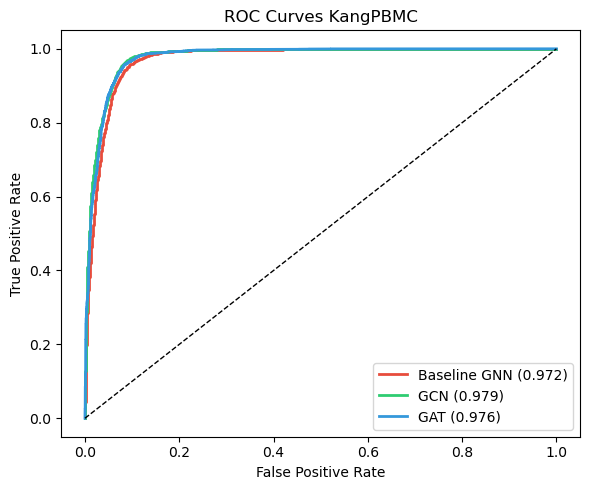

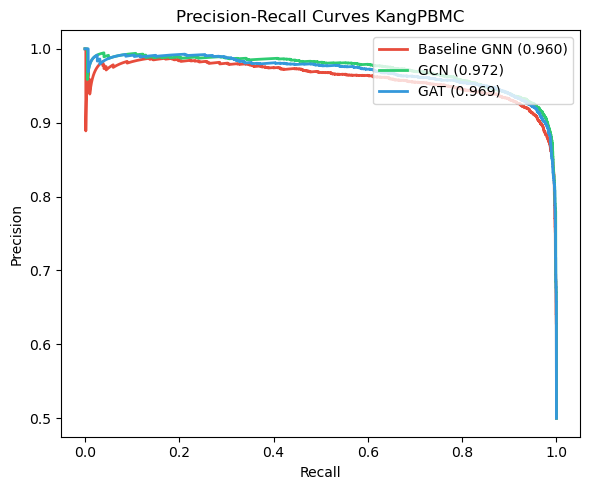

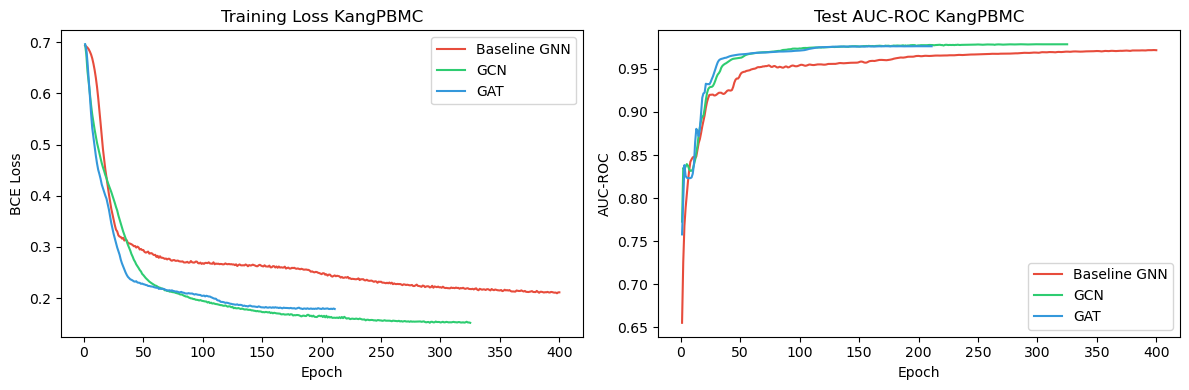

In [11]:
from src.utils import results_table, plot_roc_curves, plot_pr_curves, plot_training_history

print('\n### KangPBMC (LIANA+ dataset)')
results_table(kang_results)
plot_roc_curves(kang_results,     title='KangPBMC')
plot_pr_curves(kang_results,      title='KangPBMC')
plot_training_history(kang_histories, title='KangPBMC')

In [14]:
import os, pickle
os.makedirs('results', exist_ok=True)
with open('results/kang_results.pkl', 'wb') as f:
    pickle.dump(kang_results, f)
print('kang_results saved to results/kang_results.pkl')

kang_results saved to results/kang_results.pkl


---
## Part 4 — Cross-Dataset Comparison

Aggregate all results across all 7 datasets to assess model consistency.

In [15]:
"""
RESTORE RESULTS — run this single cell to recover all results after a kernel restart.
  - human_results : hardcoded from previously printed tables (no retraining)
  - mouse_results : quick retraining (~2-3 min, small datasets)
  - kang_results  : loaded from pickle saved during this session
"""
import os, pickle, torch
from src.secondary_datasets import load_all_mouse_datasets
from src.graph_builder import build_link_prediction_data
from src.trainer import split_data, train_model
from src.models import BaselineGNN, GCN, GAT
from src.utils import set_seed

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HIDDEN_DIM = 128
EPOCHS     = 400
LR         = 1e-3
MODEL_DEFS = {
    'Baseline GNN': (BaselineGNN, {}),
    'GCN':          (GCN,         {}),
    'GAT':          (GAT,         {'heads': 4}),
}

# ── 1. Restore human_results from previously printed table values ─────────────
def _m(auc_roc, auc_pr, acc, prec, rec, f1):
    return dict(auc_roc=auc_roc, auc_pr=auc_pr, accuracy=acc,
                precision=prec, recall=rec, f1=f1,
                fpr=[], tpr=[], prec_curve=[], rec_curve=[])

human_results = {
    'HumanD1': {
        'Baseline GNN': _m(0.9741, 0.9634, 0.9383, 0.8971, 0.9903, 0.9414),
        'GCN':          _m(0.9915, 0.9879, 0.9708, 0.9476, 0.9968, 0.9716),
        'GAT':          _m(0.9816, 0.9745, 0.9512, 0.9188, 0.9898, 0.9530),
    },
    'HumanD2': {
        'Baseline GNN': _m(0.9873, 0.9803, 0.9618, 0.9323, 0.9959, 0.9630),
        'GCN':          _m(0.9948, 0.9919, 0.9796, 0.9644, 0.9959, 0.9799),
        'GAT':          _m(0.9951, 0.9923, 0.9799, 0.9670, 0.9937, 0.9802),
    },
    'HumanD3': {
        'Baseline GNN': _m(0.9620, 0.9427, 0.9183, 0.8703, 0.9831, 0.9233),
        'GCN':          _m(0.9960, 0.9947, 0.9791, 0.9643, 0.9950, 0.9794),
        'GAT':          _m(0.9859, 0.9769, 0.9549, 0.9238, 0.9916, 0.9565),
    },
    'HumanD4': {
        'Baseline GNN': _m(0.9691, 0.9527, 0.9322, 0.8899, 0.9866, 0.9357),
        'GCN':          _m(0.9751, 0.9628, 0.9424, 0.9066, 0.9864, 0.9448),
        'GAT':          _m(0.9731, 0.9596, 0.9383, 0.9018, 0.9837, 0.9410),
    },
}
print('human_results restored from known values.')

# ── 2. Re-run mouse training (small datasets, ~2-3 min) ──────────────────────
print('\nRetraining mouse datasets...')
mouse_raw = load_all_mouse_datasets(n_features=300)
mouse_splits = {}
for name, data in mouse_raw.items():
    lp = build_link_prediction_data(data)
    train, _, test = split_data(lp, test_ratio=0.1, seed=42)
    mouse_splits[name] = (train, test)

mouse_results = {}
for ds_name, (train_data, test_data) in mouse_splits.items():
    in_dim = train_data.x.shape[1]
    print(f'\n  {ds_name}')
    mouse_results[ds_name] = {}
    for model_name, (ModelCls, kw) in MODEL_DEFS.items():
        set_seed(42)
        model = ModelCls(in_dim=in_dim, hidden_dim=HIDDEN_DIM, **kw)
        _, metrics, _ = train_model(model, train_data, test_data,
                                    epochs=EPOCHS, lr=LR, device=DEVICE, verbose=True)
        mouse_results[ds_name][model_name] = metrics

os.makedirs('results', exist_ok=True)
with open('results/mouse_results.pkl', 'wb') as f:
    pickle.dump(mouse_results, f)
print('\nmouse_results retrained and saved.')

# ── 3. Load kang_results from pickle ─────────────────────────────────────────
with open('results/kang_results.pkl', 'rb') as f:
    kang_results = pickle.load(f)
print('kang_results loaded from pickle.')

# ── 4. Save human_results too for future restores ────────────────────────────
with open('results/human_results.pkl', 'wb') as f:
    pickle.dump(human_results, f)

print('\nAll results ready.')

human_results restored from known values.

Retraining mouse datasets...
[MouseD1] nodes=821, edges=29548, features=300
[MouseD2] nodes=1061, edges=37582, features=300
[graph_builder] MouseD1 | 821 nodes | 29548 positive CCN edges
[graph_builder] MouseD2 | 1061 nodes | 37582 positive CCN edges

  MouseD1
  Epoch   50 | loss=0.4072 | AUC=0.8884 | F1=0.8374
  Epoch  100 | loss=0.3001 | AUC=0.9488 | F1=0.8972
  Epoch  150 | loss=0.2730 | AUC=0.9577 | F1=0.9133
  Epoch  200 | loss=0.2655 | AUC=0.9588 | F1=0.9143
  Epoch  250 | loss=0.2628 | AUC=0.9594 | F1=0.9152
  Early stop at epoch 280 (best AUC=0.9595)
  Epoch   50 | loss=0.6120 | AUC=0.7648 | F1=0.7131
  Epoch  100 | loss=0.3848 | AUC=0.9256 | F1=0.8727
  Epoch  150 | loss=0.2830 | AUC=0.9561 | F1=0.9074
  Epoch  200 | loss=0.2173 | AUC=0.9700 | F1=0.9295
  Epoch  250 | loss=0.1609 | AUC=0.9821 | F1=0.9481
  Epoch  300 | loss=0.1412 | AUC=0.9868 | F1=0.9568
  Epoch  350 | loss=0.1331 | AUC=0.9878 | F1=0.9602
  Epoch  400 | loss=0.1322 

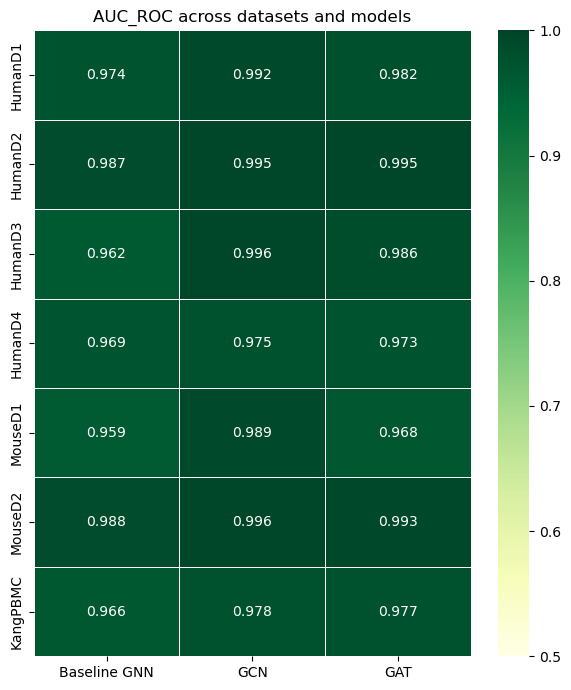

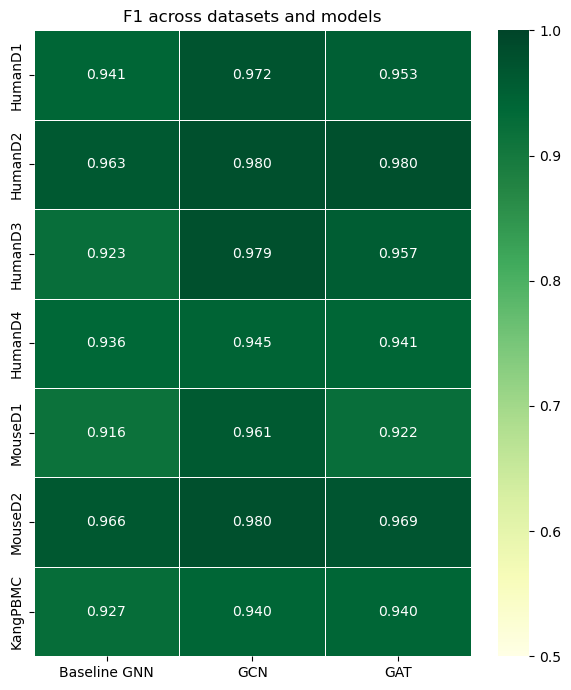

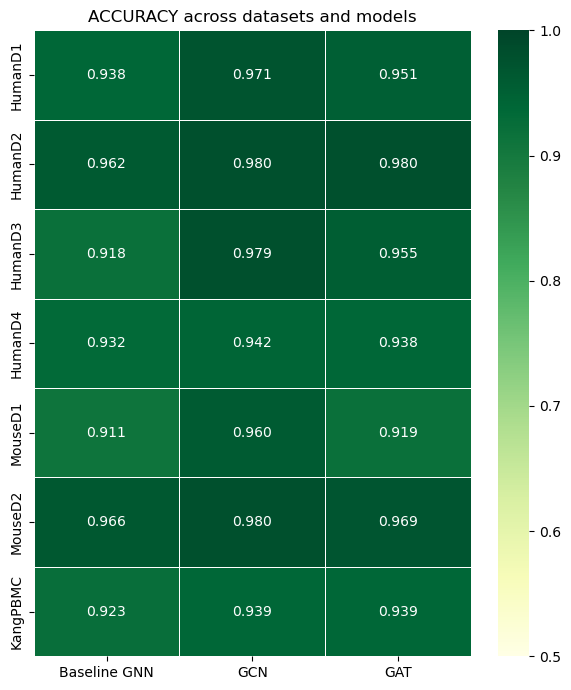

In [16]:
import pickle
from src.utils import plot_cross_dataset_heatmap

# Auto-load from checkpoints if training cells were not run this session
def _load(var, path):
    if var is None:
        with open(path, 'rb') as f:
            return pickle.load(f)
    return var

try:
    human_results
except NameError:
    human_results = _load(None, 'results/human_results.pkl')
    print('Loaded human_results from checkpoint.')

try:
    mouse_results
except NameError:
    mouse_results = _load(None, 'results/mouse_results.pkl')
    print('Loaded mouse_results from checkpoint.')

try:
    kang_results
except NameError:
    kang_results = _load(None, 'results/kang_results.pkl')
    print('Loaded kang_results from checkpoint.')

# Combine all dataset results
all_results = {**human_results, **mouse_results, 'KangPBMC': kang_results}

plot_cross_dataset_heatmap(all_results, metric='auc_roc')
plot_cross_dataset_heatmap(all_results, metric='f1')
plot_cross_dataset_heatmap(all_results, metric='accuracy')

In [17]:
import pandas as pd

metrics_keys = ['auc_roc', 'auc_pr', 'accuracy', 'precision', 'recall', 'f1']

rows = []
for ds_name, model_results in all_results.items():
    for model_name, m in model_results.items():
        rows.append({
            'Dataset': ds_name,
            'Model':   model_name,
            **{k: round(m[k], 4) for k in metrics_keys}
        })

df_all = pd.DataFrame(rows)

print('=== Full Results Table (all 7 datasets x 3 models) ===')
print(df_all.to_string(index=False))

=== Full Results Table (all 7 datasets x 3 models) ===
 Dataset        Model  auc_roc  auc_pr  accuracy  precision  recall     f1
 HumanD1 Baseline GNN   0.9741  0.9634    0.9383     0.8971  0.9903 0.9414
 HumanD1          GCN   0.9915  0.9879    0.9708     0.9476  0.9968 0.9716
 HumanD1          GAT   0.9816  0.9745    0.9512     0.9188  0.9898 0.9530
 HumanD2 Baseline GNN   0.9873  0.9803    0.9618     0.9323  0.9959 0.9630
 HumanD2          GCN   0.9948  0.9919    0.9796     0.9644  0.9959 0.9799
 HumanD2          GAT   0.9951  0.9923    0.9799     0.9670  0.9937 0.9802
 HumanD3 Baseline GNN   0.9620  0.9427    0.9183     0.8703  0.9831 0.9233
 HumanD3          GCN   0.9960  0.9947    0.9791     0.9643  0.9950 0.9794
 HumanD3          GAT   0.9859  0.9769    0.9549     0.9238  0.9916 0.9565
 HumanD4 Baseline GNN   0.9691  0.9527    0.9322     0.8899  0.9866 0.9357
 HumanD4          GCN   0.9751  0.9628    0.9424     0.9066  0.9864 0.9448
 HumanD4          GAT   0.9731  0.9596    0.9

In [18]:
print('\n=== Average across ALL datasets ===')
avg_all = df_all.groupby('Model')[metrics_keys].mean().round(4)
print(avg_all.to_string())

print('\n=== Average: Human Pancreas only ===')
avg_human = df_all[df_all.Dataset.str.startswith('Human')].groupby('Model')[metrics_keys].mean().round(4)
print(avg_human.to_string())

print('\n=== Average: Mouse Pancreas only ===')
avg_mouse = df_all[df_all.Dataset.str.startswith('Mouse')].groupby('Model')[metrics_keys].mean().round(4)
print(avg_mouse.to_string())


=== Average across ALL datasets ===
              auc_roc  auc_pr  accuracy  precision  recall      f1
Model                                                             
Baseline GNN   0.9722  0.9601    0.9359     0.8993  0.9824  0.9389
GAT            0.9819  0.9745    0.9502     0.9256  0.9796  0.9517
GCN            0.9887  0.9843    0.9644     0.9440  0.9878  0.9653

=== Average: Human Pancreas only ===
              auc_roc  auc_pr  accuracy  precision  recall      f1
Model                                                             
Baseline GNN   0.9731  0.9598    0.9376     0.8974  0.9890  0.9408
GAT            0.9839  0.9758    0.9561     0.9278  0.9897  0.9577
GCN            0.9894  0.9843    0.9680     0.9457  0.9935  0.9689

=== Average: Mouse Pancreas only ===
              auc_roc  auc_pr  accuracy  precision  recall      f1
Model                                                             
Baseline GNN   0.9734  0.9633    0.9385     0.9080  0.9771  0.9412
GAT            0

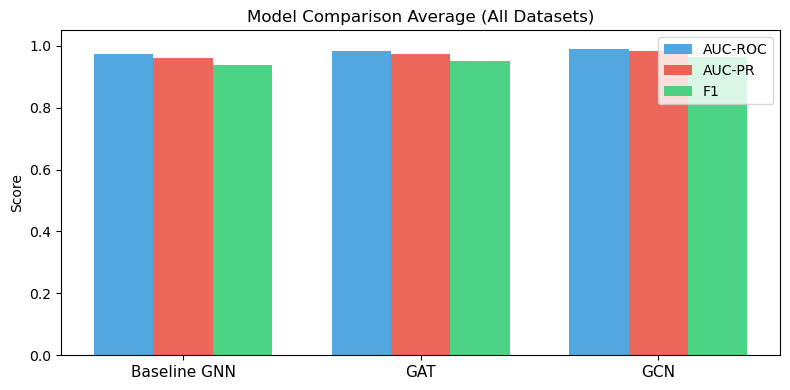

In [19]:
from src.utils import plot_metric_comparison

# Overall average comparison
avg_dict = {model: {k: float(avg_all.loc[model, k]) for k in metrics_keys}
            for model in avg_all.index}
plot_metric_comparison(avg_dict, title='Average (All Datasets)')

---
## Part 5 — Save All Results

In [20]:
import os

os.makedirs('results', exist_ok=True)

df_all.to_csv('results/all_metrics.csv', index=False)
avg_all.to_csv('results/average_metrics_all.csv')
avg_human.to_csv('results/average_metrics_human.csv')
avg_mouse.to_csv('results/average_metrics_mouse.csv')

print('Saved:')
print('  results/all_metrics.csv')
print('  results/average_metrics_all.csv')
print('  results/average_metrics_human.csv')
print('  results/average_metrics_mouse.csv')
print('  results/*.png  (all plots)')

Saved:
  results/all_metrics.csv
  results/average_metrics_all.csv
  results/average_metrics_human.csv
  results/average_metrics_mouse.csv
  results/*.png  (all plots)
